In [47]:
import numpy as np
import matplotlib.pyplot as plt
from astroML.datasets import generate_mu_z
from astroML.linear_model import LinearRegression, PolynomialRegression
from sklearn.model_selection import train_test_split

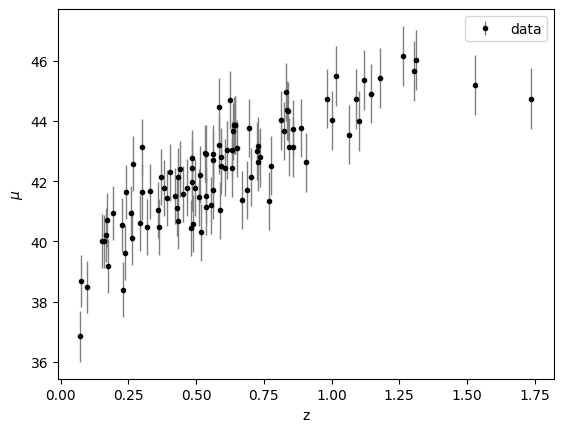

In [48]:
# Load synthetic data
z_sample, mu_sample, dmu = generate_mu_z(100, random_state=1234)

# Plot data
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend()

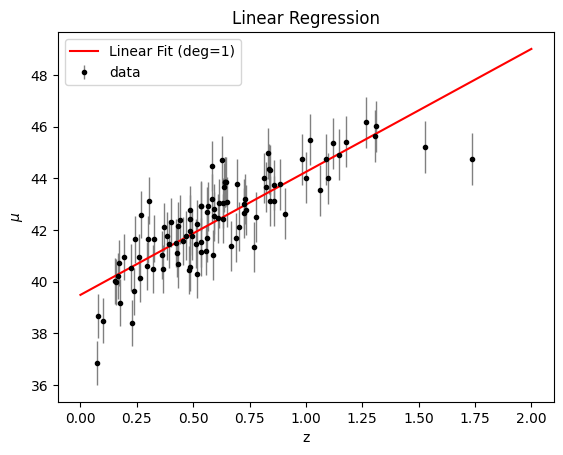

In [49]:
#Linear Regression
z_plot = np.linspace(0, 2, 1000)[:, np.newaxis]
model_lin = LinearRegression()
model_lin.fit(z_sample[:, np.newaxis], mu_sample, dmu)
mu_lin = model_lin.predict(z_plot)

plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.plot(z_plot, mu_lin, label='Linear Fit (deg=1)', color='red')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.title("Linear Regression")
plt.legend()
plt.show()

(35.0, 50.0)

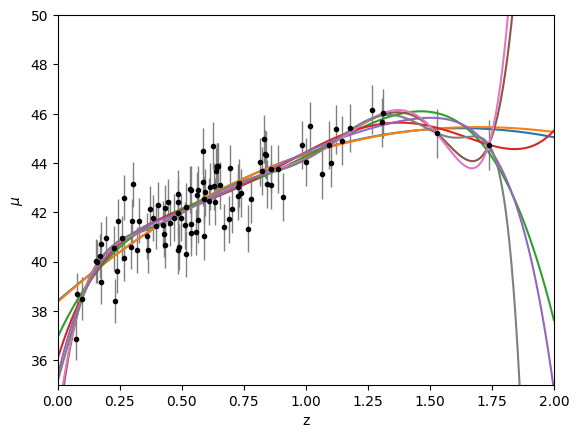

In [54]:
#Polynomial Regression
degrees = range(2, 10)
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')

for deg in degrees:
    model = PolynomialRegression(deg)
    model.fit(z_sample[:, np.newaxis], mu_sample, dmu)
    mu_fit = model.predict(z_plot)
    plt.plot(z_plot, mu_fit, label=f"deg={deg}")

plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.xlim(0, 2)
plt.ylim(35, 50)

In [55]:
# Train-test split
X = z_sample[:, np.newaxis]
y = mu_sample
dy = dmu

X_train, X_cv, yd_train, yd_cv = train_test_split(X, np.array([y, dy]).T, test_size=0.3, random_state=42)
y_train, dy_train = yd_train.T
y_cv, dy_cv = yd_cv.T

In [56]:
degrees = np.arange(1, 15)
training_err = []
crossval_err = []

for deg in degrees:
    model = PolynomialRegression(deg)
    model.fit(X_train, y_train, dy_train)

    mu_pred_train = model.predict(X_train)
    mu_pred_cv = model.predict(X_cv)

    rms_train = np.sqrt(np.mean((mu_pred_train - y_train) ** 2))
    rms_cv = np.sqrt(np.mean((mu_pred_cv - y_cv) ** 2))

    training_err.append(rms_train)
    crossval_err.append(rms_cv)


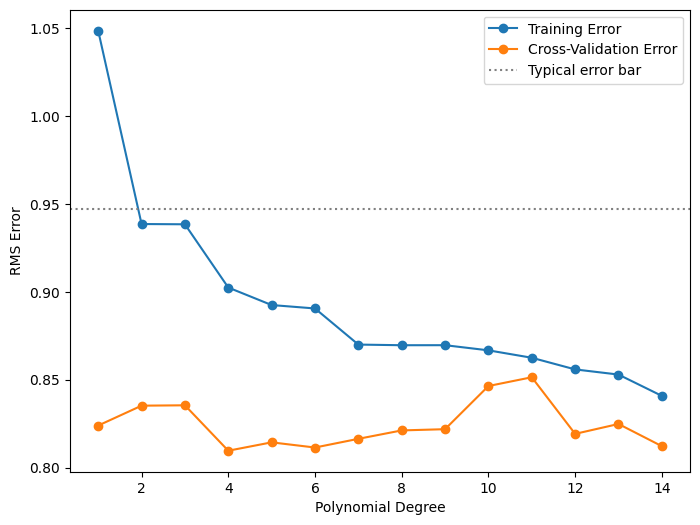

In [57]:
plt.figure(figsize=(8, 6))
plt.plot(degrees, training_err, label='Training Error', marker='o')
plt.plot(degrees, crossval_err, label='Cross-Validation Error', marker='o')
plt.axhline(np.mean(dmu), color='gray', linestyle=':', label='Typical error bar')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMS Error')
plt.legend()

In [58]:
best_deg = degrees[np.argmin(crossval_err)]
print(best_deg)

model_best = PolynomialRegression(best_deg)
model_best.fit(X, y, dy)
mu_best = model_best.predict(z_plot)

4


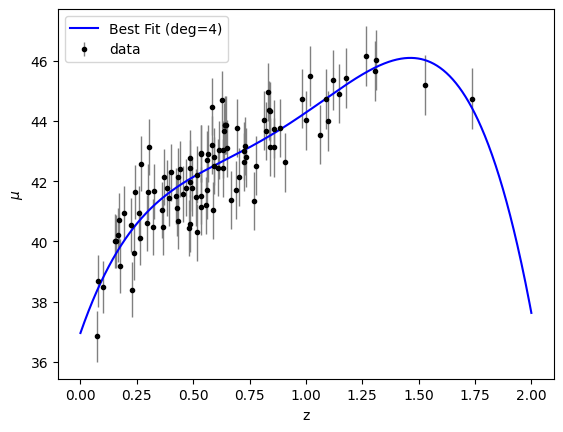

In [59]:
plt.errorbar(z_sample, mu_sample, dmu, fmt='.k', ecolor='gray', lw=1, label='data')
plt.plot(z_plot, mu_best, label=f'Best Fit (deg={best_deg})', color='blue')
plt.xlabel("z")
plt.ylabel(r"$\mu$")
plt.legend()